# NLP — 06. Bag of Words (BoW)

Now we reach an important transition in NLP.

So far, we've worked with text:

`"I love Python"`

But a machine learning model cannot directly perform mathematical operations on the word `"Python".`

We need to convert text into **numbers.**

One of the earliest and simplest ways to do this is **Bag of Words (BoW).**

## 1. What is Bag of Words?

**Bag of Words is a technique that represents text using the words that occur in it and their frequencies.**

The word **"bag"** is important.

BoW treats a sentence as a collection, or **bag**, of words and i**gnores the order of the words.**

For example: `"I love Python"` and `"Python love I"`

would contain the same words:

```
I
love
Python
```

Therefore, a basic BoW representation treats them similarly.

## 2. A simple example

Suppose we have three sentences:

```
Sentence 1: "I love Python"
Sentence 2: "I love NLP"
Sentence 3: "Python is powerful"
```

First, create a vocabulary containing all unique words and assign each word a position:

vocab: ["I", "love", "Python", "NLP", "is", "powerful"]

index: [1, 2, 3, 4, 5, 6]

Now each word has an index and Each sentence can now be represented using numbers.

## 3. Creating the vectors

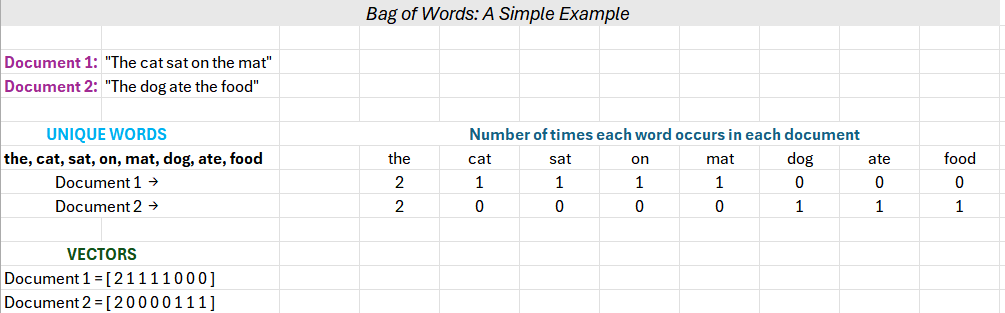

A machine learning model can work with these vectors.

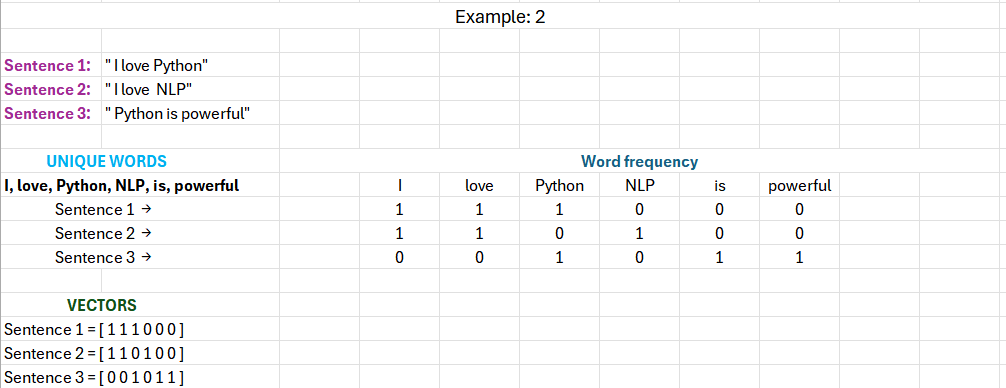

## 4. Why is it called "Bag" of Words?

Because **word order is ignored.**

Consider:

`"The dog chased the cat."`

and:

`"The cat chased the dog."`

BoW sees essentially the same collection of words:

```
the
dog
chased
cat
```

**It doesn't understand that the dog performed the action in the first sentence and the cat performed the action in the second.**

This is one of the **fundamental limitations** of BoW.

## 5. Word frequency

So far we've used:

`1 → word exists`

`0 → word doesn't exist`

But BoW can also count **how many times a word occurs.**

Consider: "Python is easy. Python is powerful."

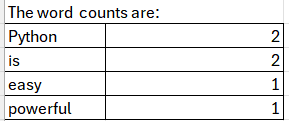

So the vector represents the **frequency** of each word.

This is called a **Count Vector** or **Count Vectorization.**

## 6. Implementing BoW manually

In [ ]:
#Let's create a very small example in Python.
sentences = [
    "I love Python",
    "I love NLP",
    "Python is powerful"
]

# Create vocabulary
vocabulary = set()

for sentence in sentences:
    vocabulary.update(sentence.lower().split())

vocabulary = sorted(vocabulary)

print(vocabulary)

['i', 'is', 'love', 'nlp', 'powerful', 'python']


In [ ]:
#Now create vectors:
vectors = []

for sentence in sentences:
    words = sentence.lower().split()

    vector = [
        words.count(word)
        for word in vocabulary
    ]

    vectors.append(vector)

print(vectors)

[[1, 0, 1, 0, 0, 1], [1, 0, 1, 1, 0, 0], [0, 1, 0, 0, 1, 1]]


In [ ]:
#We've just implemented a basic Bag of Words representation ourselves.

## 7. Using Scikit-learn

In [ ]:
#In practice, we don't need to manually implement it.
#scikit-learn provides CountVectorizer.

from sklearn.feature_extraction.text import CountVectorizer

sentences = [
    "I love Python",
    "I love NLP",
    "Python is powerful"
]

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(sentences)

In [ ]:
#Let's see the vocabulary:
print(vectorizer.get_feature_names_out())

['is' 'love' 'nlp' 'powerful' 'python']


In [ ]:
print(X.toarray())
#Each row represents one sentence.
#Each column represents one word in the vocabulary.

[[0 1 0 0 1]
 [0 1 1 0 0]
 [1 0 0 1 1]]


## 8. The biggest problem with BoW

BoW completely ignores **word order and context.**

Compare:

`"I love this movie"`

with:

`"I hate this movie"`

BoW can distinguish them because `love` and `hate` are different words.

But consider:

`"The dog chased the cat"`

and:

`"The cat chased the dog"`

They contain the same words.

BoW produces the same word counts.

But their meanings are different.

So BoW understands:

> **Which words are present?**

But not:

> **How are those words related?**

## 9. Another major problem: vocabulary size


Imagine we have:

`1,000,000 unique words`

Our vectors could potentially contain:

`[0, 0, 0, 0, 0, ... 1, 0, 0, ...]`

with **one million dimensions.**

Most entries would be zero.

This creates a **high-dimensional sparse representation.**

For example:

```
Vocabulary = 10,000 words

Document:
"I love Python"

Vector:
[0, 1, 0, 0, 0, 0, 1, ...]
```

Only a few positions contain useful information.

## 10. BoW doesn't understand meaning

Consider:

`"I love cars"`

and:

`"I adore automobiles"`

A human understands that these sentences are semantically similar.

BoW doesn't.

It sees:

`love ≠ adore`

`cars ≠ automobiles`

because each is treated as a separate vocabulary item.

This is a major limitation.

Later, **word embeddings** will solve this problem much better.

## 11. BoW limitations

Keep these four limitations in your notebook:

**1. Ignores word order**

`dog bites man`

`man bites dog`

can have the same representation.

**2. Doesn't understand semantics**

`car` `automobile`
are treated as unrelated words.

**3. High-dimensional**

Large vocabulary → very large vectors.

**4. Sparse representation**

Most values in the vector are usually `0`.


## 12. Why are we learning BoW if modern LLMs don't use it?


Because BoW introduces a fundamental idea:

> **Convert language into a numerical representation that a machine can process.**

The evolution then becomes:

```
Bag of Words
     ↓
TF-IDF
     ↓
Word Embeddings
     ↓
Contextual Embeddings
     ↓
Transformers
     ↓
LLMs
```

Each step attempts to solve limitations of the previous representation.

BoW asks:

> **"Which words appear, and how often?"**

TF-IDF will improve this by asking:

> **"How important is this word to this particular document?"**

That is our next topic.

# NLP — 07. TF-IDF

In the previous topic, we learned **Bag of Words (BoW).**

BoW answers a simple question:

> **How many times does each word appear in a document?**

That's useful, but it has a major problem.

Imagine we have 1,000 documents. Words like:

```
the
is
and
this
```

may appear in almost every document.

Their frequency can be high, but they don't tell us much about **what makes one document different from another.**

This is where **TF-IDF** comes in.

## 1. What is TF-IDF?

**TF-IDF stands for Term Frequency–Inverse Document Frequency.**

It gives a numerical score representing **how important a word is to a particular document relative to a collection of documents.**

The basic idea is:

> A word is important if it appears frequently in a particular document but does not appear frequently across all documents.

So TF-IDF combines two ideas:

```
TF  → How frequently does the word appear in this document?

IDF → How rare is the word across all documents?
```

Then: `TF-IDF = TF × IDF`

## 2. Let's understand the problem with an example

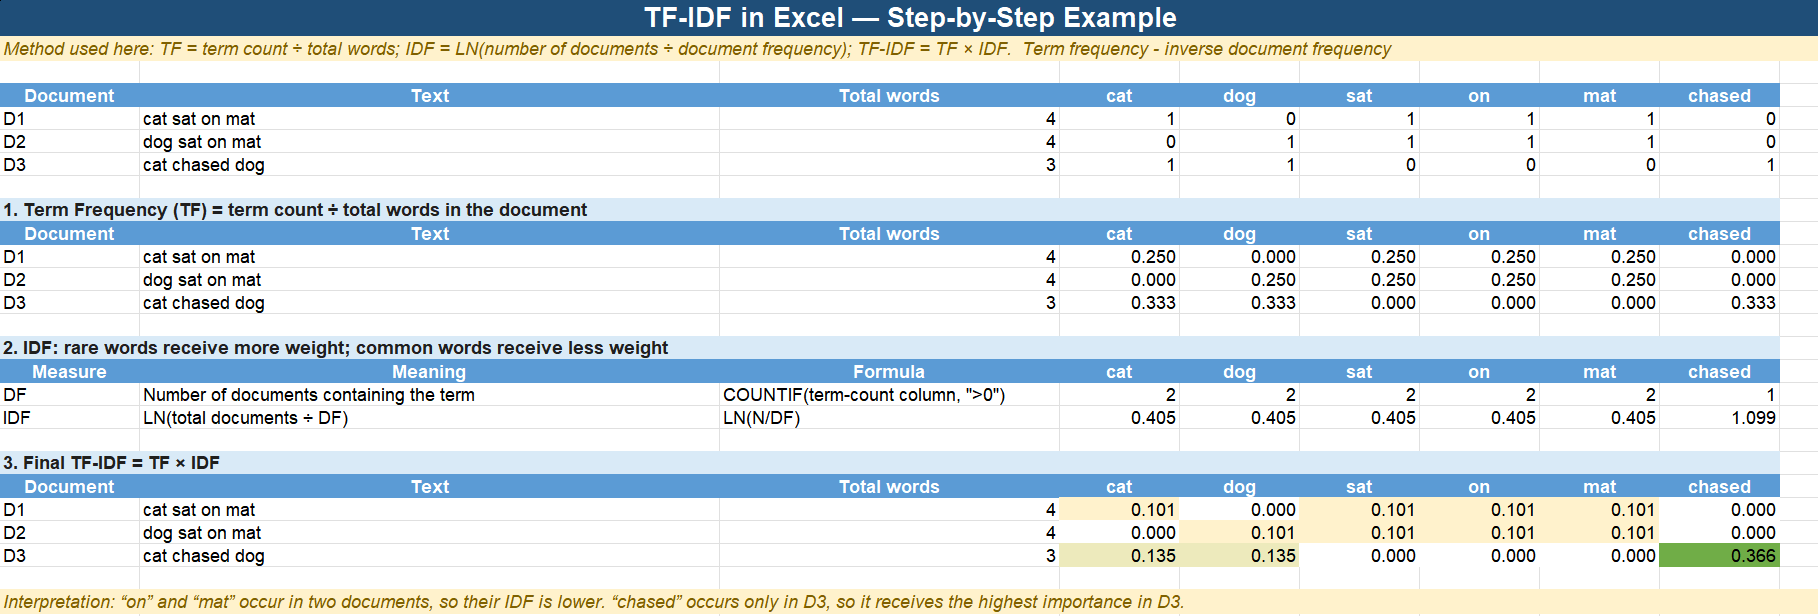

----

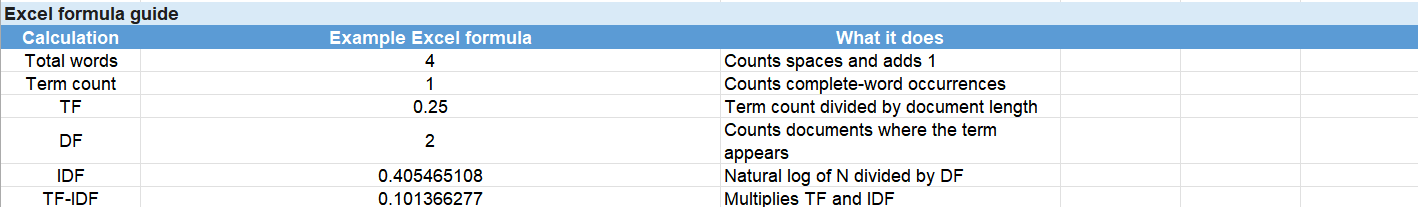

## 3. TF — Term Frequency

Term Frequency (TF) measures how frequently a word occurs in a particular document.

The simplest formula is:

$$ TF(t,d) = \frac{\text{Number of times term }t\text{ appears in document }d} {\text{Total number of terms in document }d} $$

Suppose:

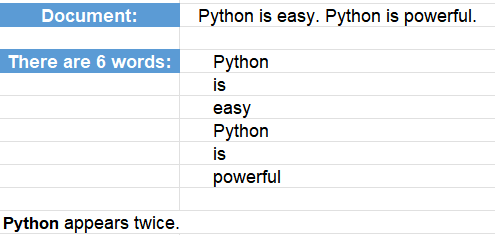

Therefore:

$$ TF(Python) = \frac{2}{6} = 0.333 $$

easy appears once:

$$ TF(easy) = \frac{1}{6} = 0.167 $$

So:

`Python → higher TF`

`easy   → lower TF`

because Python occurs more frequently in this document.

## 4. Why isn't TF alone enough?

Suppose we have 10,000 documents.

The word: `"the"`
might appear hundreds of times in one document.

Its TF could therefore be high.

But the is probably not useful for distinguishing this document from the others because it appears everywhere.

So we need another measurement:

**IDF — Inverse Document Frequency**

## 5. IDF — Inverse Document Frequency

IDF measures **how rare a word is across the entire collection of documents.**

The basic idea is:

```
Word appears in many documents
        ↓
      Low IDF

Word appears in very few documents
        ↓
      High IDF
```

A common formula is:

$$ IDF(t) = \log\left(\frac{N}{df(t)}\right) $$

where:

- `N` = total number of documents
- `df(t)` = number of documents containing the term

## 6. Simple IDF example

Suppose we have:

`N = 100 documents`

The word `"the"` appears in:

`90 documents`

Then:

$$ IDF(the) = \log(100/90) $$

This produces a **small value.**

Now suppose `"Python"` appears in only:

`10 documents`

Then:

$$ IDF(Python) = \log(100/10) $$

This produces a **larger value.**

Therefore:

`"the"    → low IDF`

`"Python" → higher IDF`

That's exactly what we want.

## 7. Combining TF and IDF

Now we combine them:

$$ TF\text{-}IDF = TF \times IDF $$

Think of it this way:

**High TF + High IDF**

```
Word appears frequently
in this document

AND

Word is relatively rare
across other documents
```

***→ High TF-IDF score***

This is a potentially important word.

---

**High TF + Low IDF**

```
Word appears frequently
in this document

BUT

Word appears everywhere
```

***→ Low TF-IDF score***

The word isn't very useful for distinguishing the document.

## 8. Intuitive example

Imagine you're searching through articles about technology.

**Document A**

> "Python is a programming language used for machine learning."

**Document B**

> "Python is popular for data science."

**Document C**

> "Football is a popular sport."

Words such as:

```
is
a
for
```

appear frequently across documents.

Their IDF will be relatively low.

But words such as:

```
programming
machine
learning
football
```

may be more useful for identifying what a document is about.

TF-IDF gives those words higher importance when they are relatively distinctive.

## 9. TF-IDF vs Bag of Words

This distinction is important.

**Bag of Words**

BoW essentially asks:

> **How often does this word occur?**

```
Python → 3
machine → 1
learning → 1
```

**TF-IDF**

TF-IDF asks:

> **How important is this word to this document compared with the entire collection?**

```
Python → 0.42
machine → 0.18
learning → 0.18
```

The exact values depend on the corpus and formula.

So:

```
BoW
↓
Raw word frequency

TF-IDF
↓
Frequency + rarity across documents
```

## 10. Implementing TF-IDF with Python

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

documents = [
    "I love Python",
    "Python is powerful",
    "I love machine learning"
]

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(documents)

In [4]:
#Let's see the vocabulary
print(vectorizer.get_feature_names_out())

['is' 'learning' 'love' 'machine' 'powerful' 'python']


In [5]:
#TF-IDF matrix
print(X.toarray())

[[0.         0.         0.70710678 0.         0.         0.70710678]
 [0.62276601 0.         0.         0.         0.62276601 0.4736296 ]
 [0.         0.62276601 0.4736296  0.62276601 0.         0.        ]]


In [6]:
#Rows    → Documents
#Columns → Words
#Values  → TF-IDF scores

## 11. Let's inspect more clearly

In [7]:
import pandas as pd

df = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
)

print(df)

         is  learning      love   machine  powerful    python
0  0.000000  0.000000  0.707107  0.000000  0.000000  0.707107
1  0.622766  0.000000  0.000000  0.000000  0.622766  0.473630
2  0.000000  0.622766  0.473630  0.622766  0.000000  0.000000


The exact numbers depend on the implementation and normalization.

Now you can visually see that different words receive different importance scores for different documents.

## 12. Why do we use logarithm in IDF?

The IDF formula uses a logarithm:

$$ IDF = \log\left(\frac{N}{df}\right) $$

The logarithm prevents extremely rare words from receiving excessively large weights.

You don't need to memorize the mathematical reason deeply at this stage.

For now, remember:

> **IDF increases as a word becomes rarer across the document collection.**

## 13. TF-IDF has an important limitation

TF-IDF understands **word importance**, but it doesn't understand **word meaning.**

For example:

```
car
automobile
vehicle
```

are semantically related.

But TF-IDF treats them as separate vocabulary terms.

It also doesn't understand context.

For example:

```
"I went to the bank to deposit money."

"The river bank was beautiful."
```

The word `bank` is treated as the same word even though its meaning is different.

So TF-IDF is still a **bag-of-words-style representation.**

It represents words independently rather than understanding their semantic relationships.

## 14. TF-IDF limitations

**1. No word order**

```
dog bites man
man bites dog
```

can have similar word-frequency representations.

**2. No semantic understanding**

```
car
automobile
```

are treated as unrelated terms.

**3. No contextual meaning**

`bank`

has the same representation regardless of its context.

**4. High-dimensional and sparse**

A large vocabulary can produce very large vectors containing mostly zeros.

**5. Doesn't capture relationships between words**

It doesn't understand that:

```
king
queen
man
woman
```

have meaningful relationships.

This limitation leads us toward the next major development in NLP:

**Word Embeddings**

Instead of representing a word simply by its frequency, embeddings represent words as **dense numerical vectors that can capture semantic relationships.**

Conceptually:

```
TF-IDF

"king" → [0, 0, 1, 0, 0, ...]
"queen" → [0, 1, 0, 0, 0, ...]
```

versus embeddings:

```
"king"   → [0.21, -0.54, 0.73, ...]
"queen"  → [0.19, -0.49, 0.71, ...]
```

The second representation can capture relationships between words.

## ✅Key Takeaways

> **TF-IDF measures how important a word is to a document relative to a collection of documents.**

Remember the three pieces:

```
TF
↓
How often is the word in this document?

IDF
↓
How rare is the word across documents?

TF-IDF
↓
TF × IDF
↓
Importance of the word
```

And the progression we've now established is:

```
Bag of Words
      ↓
TF-IDF
      ↓
Word Embeddings
      ↓
Contextual Embeddings
      ↓
Attention
      ↓
Transformers
      ↓
LLMs
```

**Next → NLP — 08. Word Embeddings**

This is the point where NLP makes a major jump: instead of merely counting words, we'll learn how to represent words as **vectors that capture relationships and semantic similarity.**

# NLP — 08. Word Embeddings

So far, we represented text using BoW and TF-IDF. Both convert words into numbers, but they have a major limitation:

> They treat words mostly as independent tokens and don't really understand relationships between words.

**Word embeddings** are the next step.

## 1. What are Word Embeddings?

A **word embedding** is a way of representing a word as a **dense numerical vector.**

Instead of representing: `king`

as a single ID like: `42`

we represent it with a vector such as:

`[0.21, -0.45, 0.78, 0.12, ...]`

For example, imagine a simplified 3-dimensional embedding:

```
king   → [0.8, 0.7, 0.6]
queen  → [0.8, 0.6, 0.7]
apple  → [0.1, 0.9, 0.2]
car    → [0.2, 0.1, 0.8]
```

Real embeddings usually have `hundreds of dimensions.`

The important idea is not the individual numbers themselves. The important thing is that **similar words tend to have similar vectors.**

## 2. Why do we need embeddings?

Consider these two sentences:

```
I love dogs.
I love puppies.
```

BoW/TF-IDF sees:

```
dogs
puppies
```

as two completely different words.

It doesn't inherently know that:
`dog ≈ puppy`

But an embedding model can learn that words appearing in similar contexts tend to have related meanings.

For example:

```
dog     → [0.72, 0.31, 0.65, ...]
puppy   → [0.70, 0.34, 0.63, ...]
car     → [0.12, 0.81, 0.21, ...]
```

The vectors for **dog** and **puppy** would be relatively close.

That's the beginning of **semantic representation.**

## 3. The key idea: meaning from context

A famous idea in NLP is:

> **You can learn a lot about a word from the words that appear around it.**

Consider:

```
The cat is drinking milk.
The dog is drinking milk.
```

`cat` and `dog` appear in similar contexts.

Another example:

```
I drove my car to work.
I drove my vehicle to work.
```

`car` and `vehicle` appear in similar contexts.

An embedding model learns these patterns from large amounts of text.

So instead of manually telling the model:

```
dog = animal
car = vehicle
```

the model **learns relationships from language data.**

## 4. Sparse vs Dense representations

This is an important distinction.

### BoW / TF-IDF

Suppose our vocabulary contains 10,000 words.

A document might be represented as:

`[0, 0, 0, 1, 0, 0, 0, 0, 2, 0, ...]`

Most values are zero.

This is a **sparse vector.**

### Embeddings

A word might instead be represented as:

`[0.21, -0.43, 0.72, 0.15, -0.09, ...]`

Most dimensions contain meaningful numerical values.

This is a `dense vector.`

So:

```
BoW / TF-IDF
       ↓
Sparse vectors
       ↓
Mostly word occurrence information
```
----
```
Word Embeddings
       ↓
Dense vectors
       ↓
Semantic relationships
```

## 5. What does each dimension mean?

This is where beginners often get confused.

Suppose:

`king → [0.72, 0.45, -0.13, 0.81, ...]`

You might ask:

> Does dimension 1 mean "royalty"?

Usually, **not directly.**

The dimensions of learned embeddings are generally **not individually interpretable.**

The meaning is distributed across many dimensions.

Think of it like a coordinate system.

Instead of:

```
Dimension 1 = royalty
Dimension 2 = gender
Dimension 3 = age
```

it's more like:

```
The entire vector
        ↓
represents the learned characteristics of the word
```

## 6. Similar words → similar vectors

One of the most useful properties of embeddings is that we can compare vectors.

Imagine:

```
king   → vector A
queen  → vector B
apple  → vector C
```

If:

```
distance(A, B) = small
distance(A, C) = large
```

then the model considers `king` and `queen` more related than `king` and `apple`.

A common measure is **cosine similarity.**

The idea is:

`similarity ≈ how close the vectors point in the same direction`

For example:

```
dog ↔ puppy       high similarity
dog ↔ cat         high similarity
dog ↔ airplane    low similarity
```

This becomes extremely important later when we study **embeddings for semantic search and RAG.**

## 7. Word embeddings can capture relationships

Good embedding models can learn relationships such as:

```
king ↔ queen
man ↔ woman
Paris ↔ France
Tokyo ↔ Japan
```

Some early embedding models even exhibited interesting vector relationships such as:

`king - man + woman ≈ queen`

Conceptually:

```
king
  ↓
remove "male" relationship
  ↓
add "female" relationship
  ↓
queen
```

This was one of the reasons Word2Vec became so influential.

But don't think of this as a universal mathematical rule. It is an observed property of some learned embedding spaces, not a guarantee for every embedding model.

## 8. Simple Python example

In [1]:
#Let's create a very small example ourselves.

import numpy as np

embeddings = {
    "dog": np.array([0.8, 0.7, 0.6]),
    "puppy": np.array([0.79, 0.72, 0.61]),
    "cat": np.array([0.75, 0.68, 0.64]),
    "car": np.array([0.1, 0.2, 0.9])
}

In [2]:
#We can calculate cosine similarity:

from sklearn.metrics.pairwise import cosine_similarity

dog = embeddings["dog"].reshape(1, -1)
puppy = embeddings["puppy"].reshape(1, -1)
car = embeddings["car"].reshape(1, -1)

print("Dog vs Puppy:",
      cosine_similarity(dog, puppy)[0][0])

print("Dog vs Car:",
      cosine_similarity(dog, car)[0][0])

Dog vs Puppy: 0.9998338183241711
Dog vs Car: 0.671384379136237


The numbers aren't meaningful because we invented these embeddings. They're just demonstrating the principle.

Real embedding models learn the vectors from data.

## 9. How are embeddings actually learned?

This is the important transition toward **Word2Vec.**

We don't normally sit down and manually create:

`dog → [0.8, 0.7, 0.6]`

Instead, we give a model lots of text.

For example:

```
The dog drinks water.
The dog likes food.
The cat drinks milk.
The cat likes food.
```

The model repeatedly looks at words and their contexts.

Over time, it adjusts the numerical vectors so that words appearing in similar contexts develop similar representations.

Very roughly:

```
Large text corpus
       ↓
Context information
       ↓
Training
       ↓
Learned vectors
       ↓
Word embeddings
```

**Word2Vec** is one of the classic algorithms designed specifically to learn these word embeddings.

## 10. Important distinction: Word Embeddings ≠ Token IDs

This is also connected to our tokenization lesson.

Suppose:
`"dog"`
gets token ID:
`512`

That `512` is not the meaning of dog.

It's simply an identifier.

Then an embedding layer can map:

```
token ID 512
       ↓
[0.72, -0.14, 0.63, ...]
```

So:

```
Token
  ↓
Token ID
  ↓
Embedding vector
```

This distinction becomes **very important when we study Transformers and LLMs.**

## ✅Key Takeaways 

> **Word embeddings represent words as dense numerical vectors where the positions of words in the vector space can capture semantic and linguistic relationships**

And the key progression is:

```
BoW / TF-IDF
→ "Which words occur?"

Word Embeddings
→ "How are words related?"

Contextual Embeddings
→ "What does this word mean in this context?"
```